In [1]:
!pip install -U diffusers transformers accelerate sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 128.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [2]:
from diffusers import DiffusionPipeline
import torch

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
pipeline = DiffusionPipeline.from_pretrained("segmind/tiny-sd", torch_dtype=torch.float16).to("cuda")



model_index.json:   0%|          | 0.00/584 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

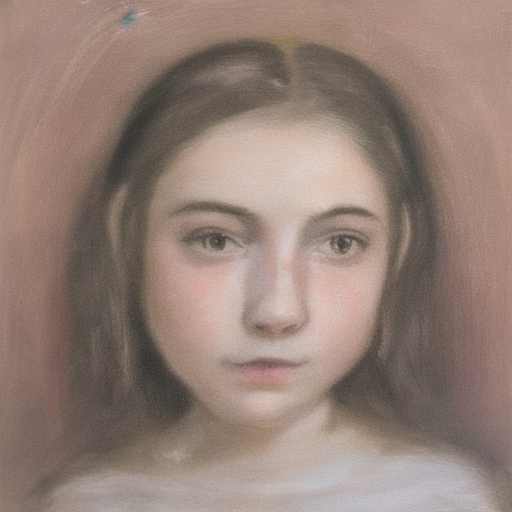

In [4]:
prompt = "preety girl"
image = pipeline(prompt).images[0]
image.save("my_image.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

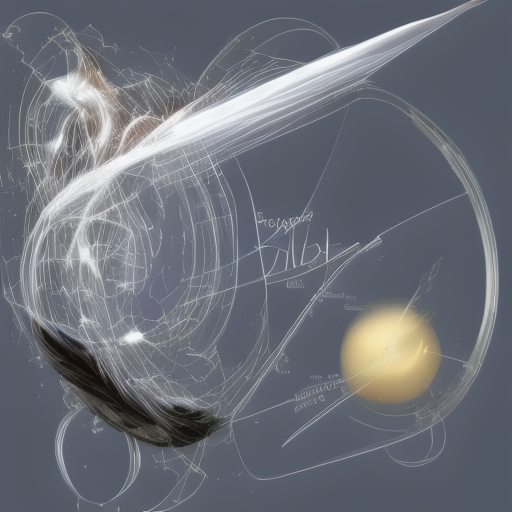

In [5]:
prompt = "newton law of motion"
image = pipeline(prompt).images[0]
image.save("my_image.png")
image

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (101 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['pairs , soft blue and white color palette , physics textbook illustration , labeled diagrams , clear typography , high detail , isometric perspective']


  0%|          | 0/50 [00:00<?, ?it/s]

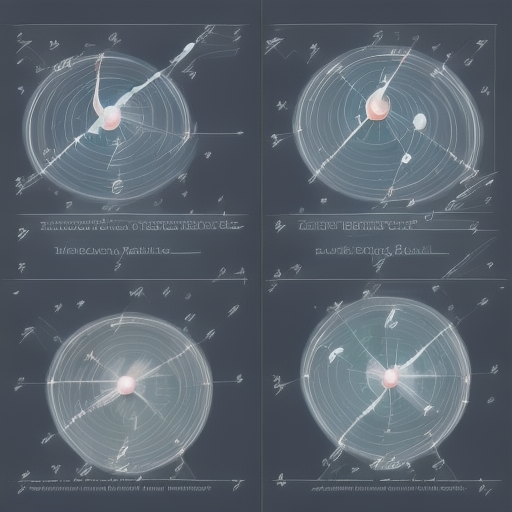

In [6]:
prompt = "Educational infographic poster illustrating Newton's three laws of motion, clean minimalist scientific diagram style, three labeled panels: first panel shows a stationary ball and a rolling ball on a frictionless surface representing inertia, second panel shows a rocket accelerating with force arrows and mass labels representing F=ma, third panel shows two ice skaters pushing apart with equal and opposite arrows representing action-reaction pairs, soft blue and white color palette, physics textbook illustration, labeled diagrams, clear typography, high detail, isometric perspective"
image = pipeline(prompt).images[0]
image.save("my_image.png")
image

In [1]:
!pip install -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 78.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [2]:
import torch
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import load_image, export_to_video


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
pipeline = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid-xt",
    torch_dtype=torch.float16,
    variant="fp16"
).to("cuda")



model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

In [4]:
pipeline.enable_model_cpu_offload()


In [5]:
image = load_image("/content/photo.png")
image = image.resize((1024, 576))  # SVD expects this resolution

In [6]:
# Generate video frames
frames = pipeline(image, decode_chunk_size=8, num_frames=25).frames[0]

# Save as video
export_to_video(frames, "generated_video.mp4", fps=7)

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/25 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


'generated_video.mp4'